# Imports

<a href="https://colab.research.google.com/github/sylvainestebe/european-city-inference/blob/main/notebooks/tutorial_1_decision_making.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

from eci.environment import EnvConfig, Environment
from eci.metrics import batch_compute_metrics
from eci.plots import plot_preference, plot_voting_metrics
from eci.utils import _extract_env_data_vectorized
from eci.voting_system.decisions import response_function
from eci.voting_system.plurality import _vote_plurality
from eci.voting_system.quadratic import _vote_quadratic

# TODO: restore `strategic_vote` and `strategic_quadratic_vote` (currently
# commented out in plurality.py / quadratic.py).

# Parameters

In [2]:
config = EnvConfig(
    num_voters=50,
    num_candidates=4,
    num_preferences=4,
)
NUM_SIMULATIONS = 100

# Environement

In [3]:
env = Environment(config)
env.num_simulations = NUM_SIMULATIONS

# Changing preferences of two groups

In [4]:
ID_THRESHOLD = 25

for voter in env.voters:
    if voter.id > ID_THRESHOLD:
        # This loop sets *every* preference index for this voter
        for preference_ixd in range(config.num_preferences):
            voter.preferences["mean"] = (
                voter.preferences["mean"].at[preference_ixd].set(3.0)
            )
            voter.preferences["precision"] = (
                voter.preferences["precision"].at[preference_ixd].set(1.5)
            )
    else:
        for preference_ixd in range(config.num_preferences):
            voter.preferences["mean"] = (
                voter.preferences["mean"].at[preference_ixd].set(-3.0)
            )
            voter.preferences["precision"] = (
                voter.preferences["precision"].at[preference_ixd].set(1.3)
            )

In [5]:
env.candidates[0].policy["mean"] = jnp.array([1, 1, 1, 1])
env.candidates[0].policy["precision"] = jnp.array([0.4, 0.4, 0.4, 0.4])

env.candidates[1].policy["mean"] = jnp.array([-1, -1, -1, -1])
env.candidates[1].policy["precision"] = jnp.array([0.5, 0.5, 0.5, 0.5])

env.candidates[2].policy["mean"] = jnp.array([2.2, 2.2, 2.2, 2.2])
env.candidates[2].policy["precision"] = jnp.array([0.6, 0.5, 0.3, 0.4])

env.candidates[3].policy["mean"] = jnp.array([1, 1, 1, 1])
env.candidates[3].policy["precision"] = jnp.array([0.2, 0.4, 0.4, 0.4])

# Do the same for candidates
env.candidates[0].policy["mean"] = (
    env.candidates[0].policy["mean"].at[0].set(2.0).at[1].set(2.0)
)
env.candidates[0].policy["precision"] = (
    env.candidates[0].policy["precision"].at[0].set(1.0).at[1].set(1.0)
)

# Do the same for candidates
env.candidates[1].policy["mean"] = (
    env.candidates[1].policy["mean"].at[0].set(-2.0).at[1].set(-2.0)
)
env.candidates[1].policy["precision"] = (
    env.candidates[1].policy["precision"].at[0].set(1.0).at[1].set(1.0)
)

/Users/sylvainestebe/Code/european-city-inference/.venv/lib/python3.12/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float32 to dtype=int32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Then we can change the distribution of voters

In [6]:
env._run_multi_agent_inference()

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_98362/4094136909.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


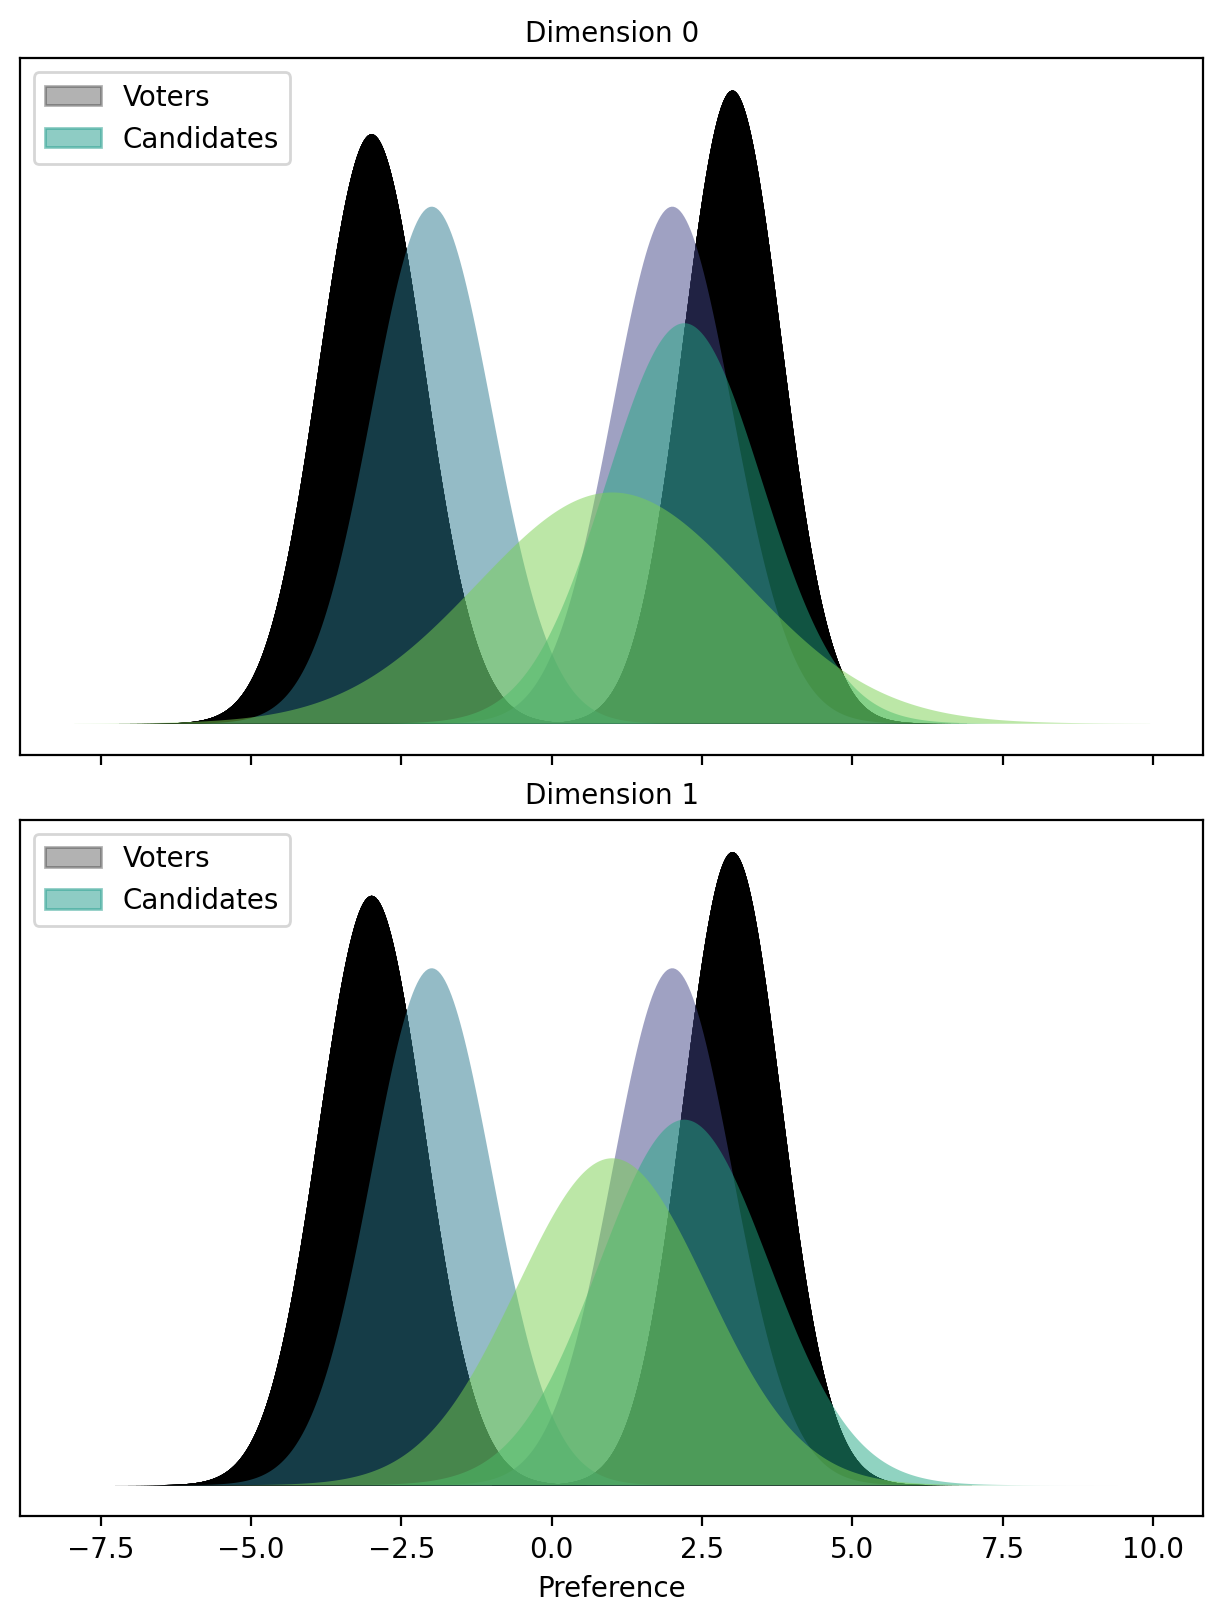

In [7]:
data = _extract_env_data_vectorized(env)
fig, ax = plot_preference(data)
fig.show()

# Run simulation

In [ ]:
data = _extract_env_data_vectorized(env)
key = jax.random.PRNGKey(42)
# Run simulations
sim_plurality = env.run_n_simulation(
    func=_vote_plurality,
    data=data,
    response_function=response_function,
    key=key,
    n_simulations=NUM_SIMULATIONS,
)
# sim_plurality_strat = env.run_n_simulation(func=strategic_vote, data=data,
# response_function=response_function, key=key, n_simulations=NUM_SIMULATIONS)
# Compute metrics
metrics_plurality = batch_compute_metrics(sim_plurality)
# metrics_plurality_strat = batch_compute_metrics(sim_plurality_strat)

Running Simulations: 100%|██████████| 100/100 [00:00<00:00, 249.69it/s]


In [ ]:
# Run simulations
sim_qv = env.run_n_simulation(
    _vote_quadratic,
    data=data,
    response_function=response_function,
    key=key,
    n_simulations=NUM_SIMULATIONS,
)
# sim_qv_strat = env.run_n_simulation(strategic_quadratic_vote, data=data,
# response_function=response_function, key=key, n_simulations=NUM_SIMULATIONS)

# Compute metrics
metrics_qv = batch_compute_metrics(sim_qv)
# metrics_qv_strat = batch_compute_metrics(sim_qv_strat)

Running Simulations: 100%|██████████| 100/100 [00:00<00:00, 513.46it/s]


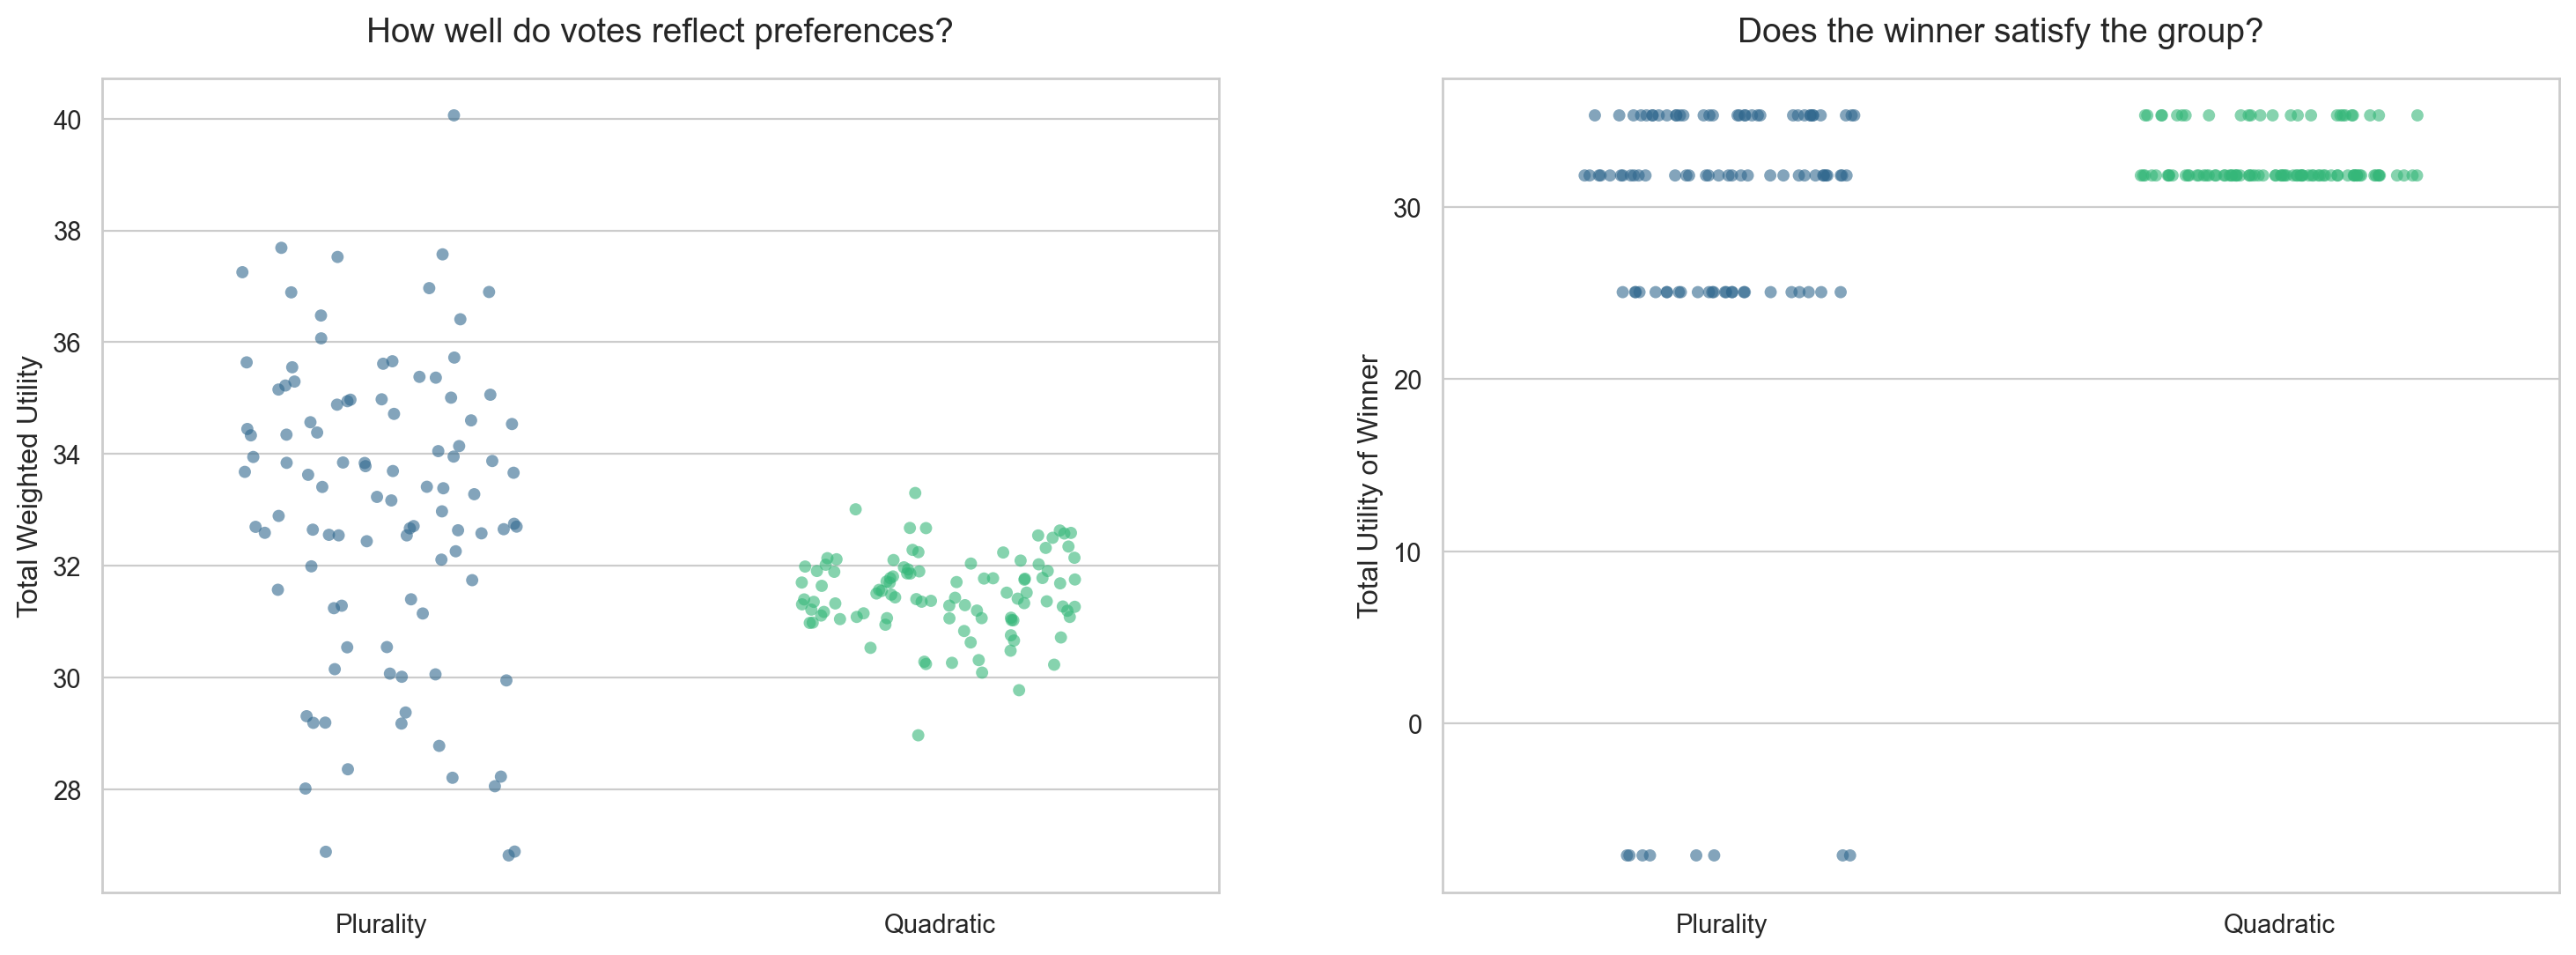

In [10]:
# change voting system labels
metrics_plurality["voting_system"] = "Plurality"
# metrics_plurality_strat["voting_system"] = "Plurality_Strat"
metrics_qv["voting_system"] = "Quadratic"
# metrics_qv_strat["voting_system"] = "Quadrati_Strat"

# combine dataframes
combined_df = pd.concat(
    [
        metrics_plurality,
        metrics_qv,
    ],
    ignore_index=True,
)

# plot voting metrics
fig = plot_voting_metrics(combined_df)
plt.show()